<a href="https://colab.research.google.com/github/ssk-algoverse/sae-binding/blob/main/sae/sae_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Mon Aug 25 01:21:37 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.153.02             Driver Version: 570.153.02     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:09:00.0 Off |                  N/A |
|  0%   33C    P8             20W /  575W |       0MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install transformer-lens dictionary-learning


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 162.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 10.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 220.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 279.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 208.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 184.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 208.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 144.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 71.0 MB/s eta

In [ ]:
import torch
from transformer_lens import HookedTransformer, HookedTransformerConfig
import numpy as np
import pandas as pd
import ast
from torch.utils.data import Dataset, DataLoader

from huggingface_hub import hf_hub_download


REPO_ID = "sebastianhoenig/2L2H_Final"
FILENAME = "D256_L2_H2_attnOnly1_lr5.0e-04_wd0.01.pt"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)
try:
    from IPython.display import clear_output
    clear_output()
except ImportError:
    pass  # clear_output not available, continue anyway

import numpy as np
import pandas as pd
from tqdm import tqdm

E = 100  # num entities
T = 10   # num types/relations

SEP = E + T
Q = E + T + 1
PAD = E + T + 2
D_VOCAB = E + T + 3

IGNORE_INDEX = -100
ENTITIES = np.arange(0, E)
TYPES    = np.arange(E, E + T)

N_WORLDS = 80_000
MIN_FACTS, MAX_FACTS = 4, 8
SEED = 0

rng = np.random.default_rng(SEED)

def produce_example_by_index(idx: int, *, allow_self_loops: bool = False):
    rng = np.random.default_rng(np.random.SeedSequence([BASE_SEED, idx]))

    k = int(rng.integers(MIN_FACTS, MAX_FACTS + 1))

    facts = []
    seen_head_rel = set()
    while len(facts) < k:
        e = int(rng.integers(0, E))
        t = int(rng.integers(0, T)) + E
        if (e, t) in seen_head_rel:
            continue
        e2 = int(rng.integers(0, E))
        while (not allow_self_loops) and e2 == e:
            e2 = int(rng.integers(0, E))
        seen_head_rel.add((e, t))
        facts.append((e, t, e2))

    q_idx = int(rng.integers(0, k))
    Eq, Tq, E2q = facts[q_idx]

    if rng.random() < 0.75 and len(facts) < MAX_FACTS:
        distractor_t = int(rng.integers(0, T)) + E

        while distractor_t == Tq: # Ensure the relation is different
            distractor_t = int(rng.integers(0, T)) + E

        distractor_e2 = int(rng.integers(0, E))
        while distractor_e2 == E2q: # Ensure the tail is different
            distractor_e2 = int(rng.integers(0, E))

        # Add the distractor fact IF it doesn't create a collision
        if (Eq, distractor_t) not in seen_head_rel:
            distractor_fact = (Eq, distractor_t, distractor_e2)

            insert_pos = int(rng.integers(0, len(facts) + 1))
            facts.insert(insert_pos, distractor_fact)

    seq = []
    for (e, t, e2) in facts:
        seq.extend([e, t, e2, SEP])

    seq.extend([Tq, Eq, Q])

    label = E2q
    return seq, label
TOTAL_TRAIN = 16_100_000
BLOCK_SIZE  = 80_000
VAL_SIZE = 20_000
TRAIN_OFFSET = VAL_SIZE
TRAIN_SIZE   = TOTAL_TRAIN
BASE_SEED = 0

class ValDataset(torch.utils.data.Dataset):
    def __len__(self): return VAL_SIZE
    def __getitem__(self, i):
        seq, label = produce_example_by_index(i)
        return torch.tensor(seq, dtype=torch.long), torch.tensor(label, dtype=torch.long)


class TrainStream(torch.utils.data.IterableDataset):
    def __init__(self, block_size=BLOCK_SIZE, offset=TRAIN_OFFSET, size=TRAIN_SIZE):
        super().__init__()
        self.block_size = block_size
        self.offset = offset
        self.size = size
        self._epoch = 0

    def set_epoch(self, epoch:int):
        self._epoch = epoch

    def __iter__(self):
        # compute which block to serve this epoch, with wrap-around
        start_in_train = (self._epoch * self.block_size) % self.size
        # stream exactly block_size samples each epoch
        for i in range(self.block_size):
            local_idx = (start_in_train + i) % self.size
            global_idx = self.offset + local_idx
            seq, label = produce_example_by_index(global_idx)
            x = torch.tensor(seq, dtype=torch.long)
            y = torch.tensor(label, dtype=torch.long)
            yield x, y

    def __len__(self):
        return self.block_size

val_dataset = ValDataset()
train_dataset = TrainStream()

N_LAYERS = 2
HEADS = 2

d_model = 256
n_ctx   = 64

def build_model(n_layers: int, n_heads: int) -> HookedTransformer:
    if d_model % n_heads != 0:
        return None
    d_head = d_model // n_heads

    cfg = HookedTransformerConfig(
        n_layers=n_layers,
        n_heads=n_heads,
        d_model=d_model,
        d_head=d_head,
        n_ctx=n_ctx,
        d_vocab=D_VOCAB,
        d_vocab_out=E,
        attn_only=True,
        normalization_type="LN",
        positional_embedding_type="rotary",
    )
    return HookedTransformer(cfg)

model = build_model(N_LAYERS, HEADS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Load the model
pretrained_weights = torch.load(weights_path, map_location=device, weights_only=True)
state_dict = pretrained_weights["model"]
model.load_state_dict(state_dict)

print("Model loaded successfully.")


def collate_fn(batch):
    max_len = max(len(seq) for seq,_ in batch)
    B = len(batch)
    toks   = torch.full((B, max_len), PAD, dtype=torch.long)
    target = torch.full((B, max_len), IGNORE_INDEX, dtype=torch.long)

    for i, (seq, label) in enumerate(batch):
        x = torch.tensor(seq if isinstance(seq, list) else seq.tolist(), dtype=torch.long)
        L = len(x)
        toks[i, :L] = x
        q_pos = (x == Q).nonzero(as_tuple=False).squeeze()
        assert q_pos.numel() == 1, "Each example must have exactly one Q"
        target[i, q_pos.item()] = int(label)
    return toks, target

Moving model to device:  cuda
Model loaded successfully.


In [ ]:
"""### Train a SAE using StandardTrainer with your datasets"""

import torch as t
from dictionary_learning.trainers.standard import StandardTrainer
from dictionary_learning import AutoEncoder, utils
from torch.utils.data import DataLoader

# === Pick activation site ===
layer = 1
act_name = f"blocks.{layer}.hook_resid_post"

# === SAE trainer ===
trainer = StandardTrainer(
    steps=100_000,                  # total training steps
    activation_dim=model.cfg.d_model,
    dict_size=128,                 # size of dictionary (SAE hidden dim) - reduced for faster training
    layer=layer,
    lm_name="entity_binding_model",  # just a string identifier
    lr=1e-4,
    l1_penalty=1e-3,
    device=device,
    warmup_steps=1000,             # learning rate warmup
    sparsity_warmup_steps=2000,    # sparsity penalty warmup
)

print(f"SAE initialized: dict_size={trainer.ae.dict_size}, activation_dim={trainer.ae.activation_dim}")

# === DataLoaders ===
train_loader = DataLoader(train_dataset, batch_size=64, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, collate_fn=collate_fn)

# === Training Loop ===
step = 0
best_loss = float('inf')
best_mse_loss = float('inf')
best_sparsity_loss = float('inf')
epochs_no_improve = 0
early_stopping_patience = 10

print("Starting SAE training...")

for epoch in range(200):   # loop over epochs
    epoch_loss = 0.0
    epoch_mse_loss = 0.0
    epoch_sparsity_loss = 0.0
    num_batches = 0

    # Set epoch for TrainStream
    train_dataset.set_epoch(epoch)

    for toks, _ in train_loader:
        toks = toks.to(device)

        # run model & collect activations
        with torch.no_grad():
            cache = model.run_with_cache(toks, names_filter=[act_name])[1]
            acts = cache[act_name]   # shape: [batch, seq, d_model]
            # flatten (batch * seq, d_model)
            acts = acts.reshape(-1, acts.size(-1))

        # update SAE
        trainer.update(step, acts)

        if step % 500 == 0:
            log = trainer.loss(acts, step, logging=True)
            current_loss = log.losses['loss']
            current_mse = log.losses['mse_loss']
            current_sparsity = log.losses['sparsity_loss']
            print(f"Step {step}: loss={current_loss:.4f}, mse={current_mse:.4f}, sparsity={current_sparsity:.4f}")

            # Accumulate loss for epoch tracking
            epoch_loss += current_loss
            epoch_mse_loss += current_mse
            epoch_sparsity_loss += current_sparsity
            num_batches += 1

        step += 1
        if step >= trainer.steps:
            break

    if num_batches > 0:
        avg_epoch_loss = epoch_loss / num_batches
        avg_epoch_mse_loss = epoch_mse_loss / num_batches
        avg_epoch_sparsity_loss = epoch_sparsity_loss / num_batches

        print(f"Epoch {epoch}: Avg Loss={avg_epoch_loss:.4f}, Avg MSE={avg_epoch_mse_loss:.4f}, Avg Sparsity={avg_epoch_sparsity_loss:.4f}")

        # Check for improvement
        if avg_epoch_loss < best_loss or avg_epoch_mse_loss < best_mse_loss or avg_epoch_sparsity_loss < best_sparsity_loss:
            best_loss = min(best_loss, avg_epoch_loss)
            best_mse_loss = min(best_mse_loss, avg_epoch_mse_loss)
            best_sparsity_loss = min(best_sparsity_loss, avg_epoch_sparsity_loss)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epochs.")

        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered after {epoch + 1} epochs.")
            break

    if step >= trainer.steps:
        break

print("SAE training completed!")


SAE initialized: dict_size=128, activation_dim=256
Starting SAE training...
Step 0: loss=27.6109, mse=27.6109, sparsity=2.3253
Step 500: loss=5.6432, mse=5.6366, sparsity=26.2746
Step 1000: loss=1.5315, mse=1.5105, sparsity=41.8212
Epoch 0: Avg Loss=11.5952, Avg MSE=11.5860, Avg Sparsity=23.4737
Step 1500: loss=0.6691, mse=0.6323, sparsity=49.1567
Step 2000: loss=0.4430, mse=0.3929, sparsity=50.0673
Epoch 1: Avg Loss=0.5560, Avg MSE=0.5126, Avg Sparsity=49.6120
Step 2500: loss=0.3228, mse=0.2703, sparsity=52.5113
Step 3000: loss=0.2406, mse=0.1883, sparsity=52.2498
Step 3500: loss=0.2059, mse=0.1542, sparsity=51.6976
Epoch 2: Avg Loss=0.2564, Avg MSE=0.2042, Avg Sparsity=52.1529
Step 4000: loss=0.1797, mse=0.1293, sparsity=50.4178
Step 4500: loss=0.1583, mse=0.1088, sparsity=49.4316
Epoch 3: Avg Loss=0.1690, Avg MSE=0.1191, Avg Sparsity=49.9247
Step 5000: loss=0.1497, mse=0.1014, sparsity=48.2995
Step 5500: loss=0.1373, mse=0.0909, sparsity=46.4232
Step 6000: loss=0.1245, mse=0.0796, s

In [ ]:
# === Save trained SAE ===
save_path = f"{act_name}_trained.pt"
t.save(trainer.ae.state_dict(), save_path)
print(f"SAE saved to {save_path}")

SAE saved to blocks.1.hook_resid_post_trained.pt


In [ ]:
# === Evaluate on validation set ===
print("\nEvaluating SAE on validation set...")
trainer.ae.eval()
val_losses = []
val_sparsity = []

with torch.no_grad():
    for toks, _ in val_loader:
        toks = toks.to(device)
        cache = model.run_with_cache(toks, names_filter=[act_name])[1]
        acts = cache[act_name]
        acts = acts.reshape(-1, acts.size(-1))

        # Get features and reconstruction
        features = trainer.ae.encode(acts)
        reconstruction = trainer.ae.decode(features)

        # Compute metrics
        mse_loss = torch.nn.functional.mse_loss(acts, reconstruction)
        sparsity = (features == 0).float().mean()

        val_losses.append(mse_loss.item())
        val_sparsity.append(sparsity.item())

avg_val_loss = np.mean(val_losses)
avg_val_sparsity = np.mean(val_sparsity)
print(f"Validation MSE: {avg_val_loss:.6f}")
print(f"Validation Sparsity: {avg_val_sparsity:.4f} ({avg_val_sparsity*100:.2f}%)")


Evaluating SAE on validation set...
Validation MSE: 0.000035
Validation Sparsity: 0.0550 (5.50%)


In [ ]:
# === Extract SAE features from validation set ===
print("\nExtracting SAE features from validation set...")
all_features = []
all_activations = []
all_reconstructions = []

with torch.no_grad():
    for toks, _ in val_loader:
        toks = toks.to(device)
        cache = model.run_with_cache(toks, names_filter=[act_name])[1]
        acts = cache[act_name]
        acts = acts.reshape(-1, acts.size(-1))

        # Extract features
        features = trainer.ae.encode(acts)
        reconstruction = trainer.ae.decode(features)

        all_features.append(features.cpu())
        all_activations.append(acts.cpu())
        all_reconstructions.append(reconstruction.cpu())

# Concatenate all features
all_features = torch.cat(all_features, dim=0)
all_activations = torch.cat(all_activations, dim=0)
all_reconstructions = torch.cat(all_reconstructions, dim=0)

print(f"Extracted features shape: {all_features.shape}")
print(f"Original activations shape: {all_activations.shape}")
print(f"Reconstructions shape: {all_reconstructions.shape}")


Extracting SAE features from validation set...
Extracted features shape: torch.Size([700000, 128])
Original activations shape: torch.Size([700000, 256])
Reconstructions shape: torch.Size([700000, 256])


In [ ]:
# === Analyze feature statistics ===
print("\n=== SAE Feature Analysis ===")
sparsity = (all_features == 0).float().mean()
print(f"Overall feature sparsity: {sparsity:.4f} ({sparsity*100:.2f}% of features are zero)")

# Feature activation frequency
feature_activations = (all_features > 0).float()
feature_frequency = feature_activations.mean(dim=0)
print(f"\nTop 10 most active features:")
top_features = feature_frequency.topk(10)
for i, (idx, freq) in enumerate(zip(top_features.indices, top_features.values)):
    print(f"  Feature {idx.item()}: {freq.item():.4f}")

# Sparsity per sample
sparsity_per_sample = (all_features == 0).float().mean(dim=1)
print(f"\nSparsity per sample - Mean: {sparsity_per_sample.mean():.4f}, Std: {sparsity_per_sample.std():.4f}")

# Reconstruction quality
reconstruction_error = torch.norm(all_activations - all_reconstructions, dim=1)
print(f"Reconstruction error - Mean: {reconstruction_error.mean():.4f}, Std: {reconstruction_error.std():.4f}")

print(f"\n✅ SAE training and feature extraction completed!")
print(f"Features saved in 'all_features' tensor with shape {all_features.shape}")
print(f"You can now use these features for interpretability analysis or downstream tasks.")

# Save features to file
features_save_path = f"{act_name}_features.pt"
torch.save({
    'features': all_features,
    'activations': all_activations,
    'reconstructions': all_reconstructions,
    'feature_frequency': feature_frequency,
    'sparsity_per_sample': sparsity_per_sample,
    'reconstruction_error': reconstruction_error
}, features_save_path)
print(f"Features saved to {features_save_path}")


=== SAE Feature Analysis ===
Overall feature sparsity: 0.0550 (5.50% of features are zero)

Top 10 most active features:
  Feature 106: 0.9863
  Feature 65: 0.9860
  Feature 110: 0.9851
  Feature 100: 0.9834
  Feature 84: 0.9821
  Feature 125: 0.9794
  Feature 12: 0.9789
  Feature 127: 0.9785
  Feature 40: 0.9779
  Feature 59: 0.9767

Sparsity per sample - Mean: 0.0550, Std: 0.0385
Reconstruction error - Mean: 0.0869, Std: 0.0363

✅ SAE training and feature extraction completed!
Features saved in 'all_features' tensor with shape torch.Size([700000, 128])
You can now use these features for interpretability analysis or downstream tasks.
Features saved to blocks.1.hook_resid_post_features.pt


In [ ]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


Creating SAE feature visualizations...


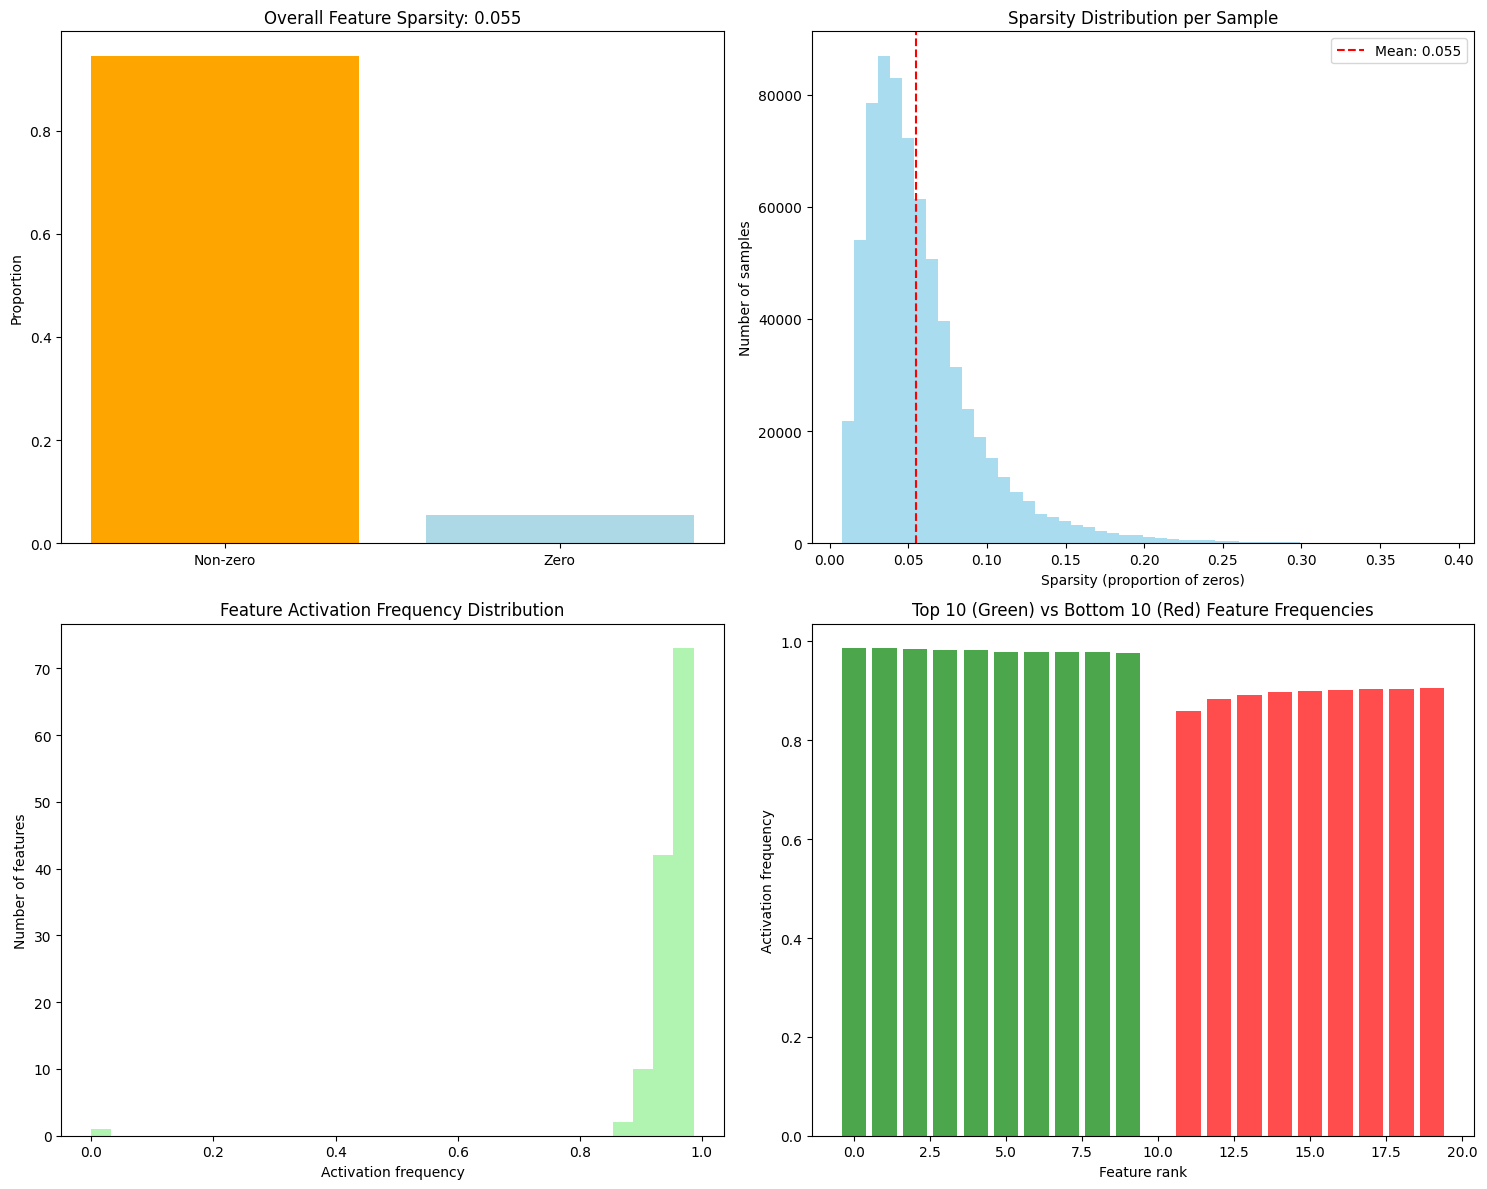

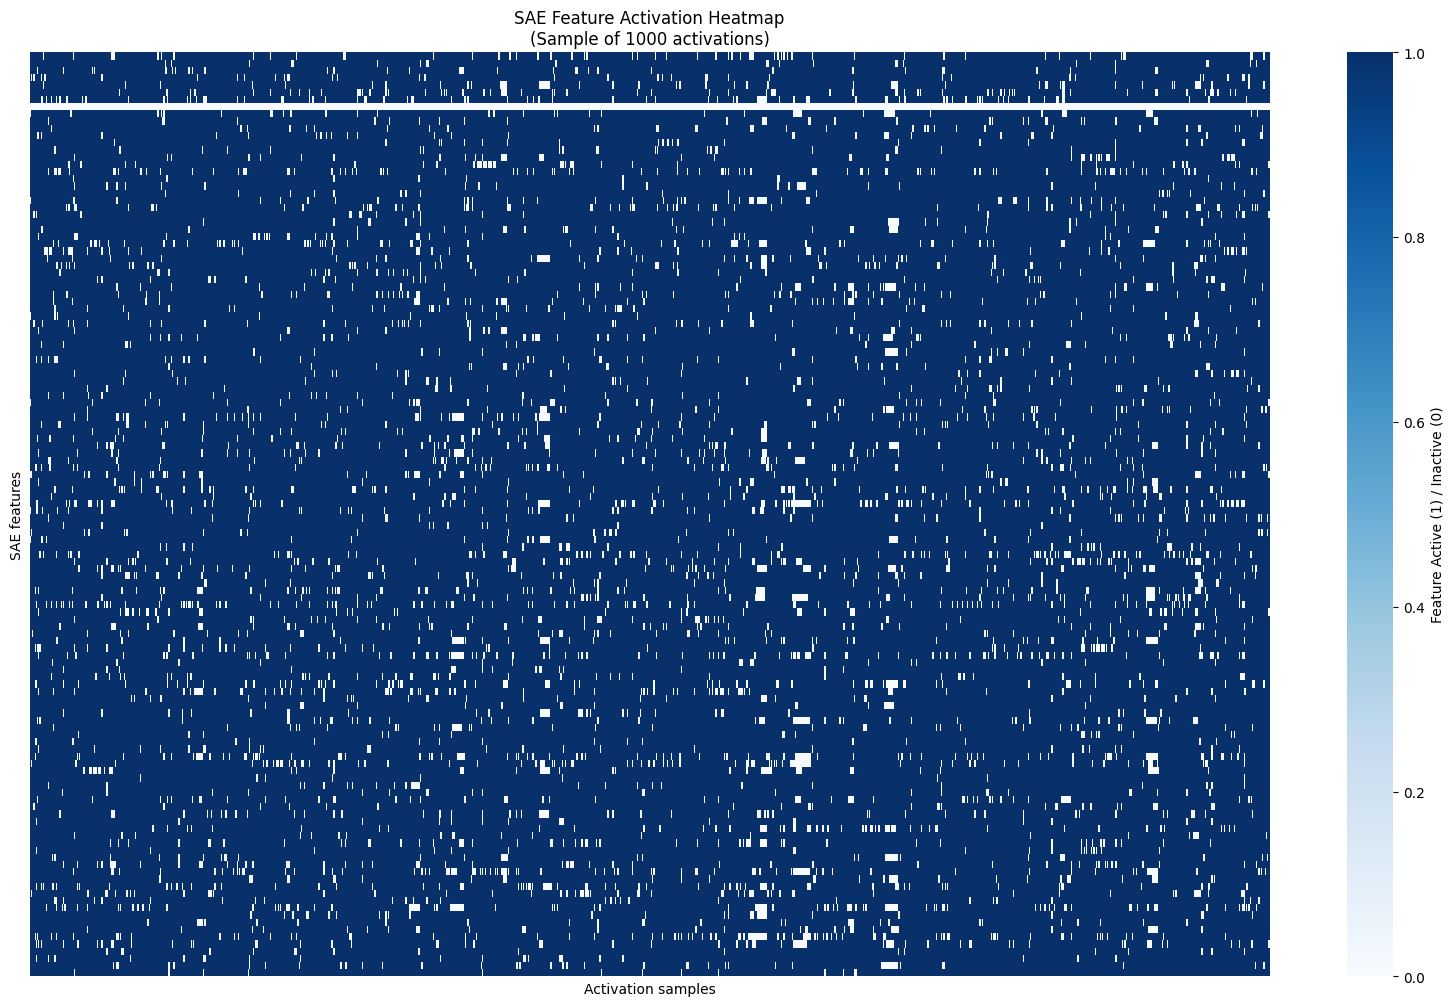

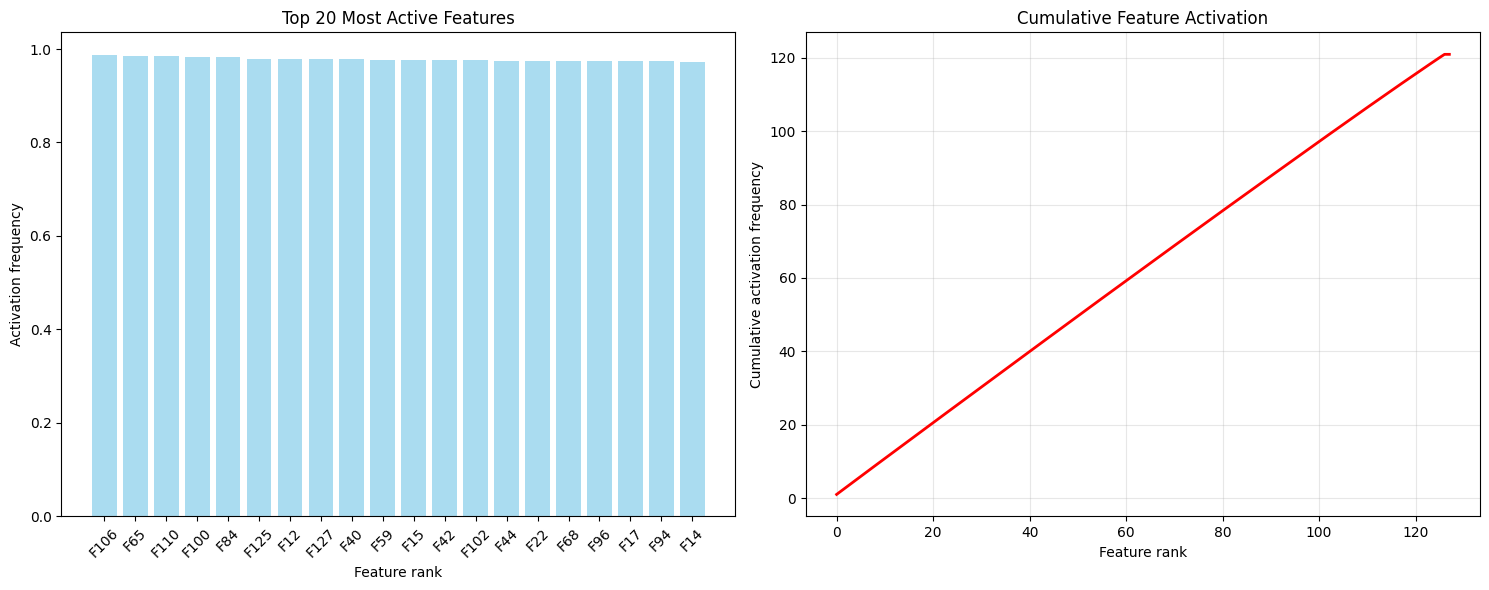

ValueError: x and y must be the same size

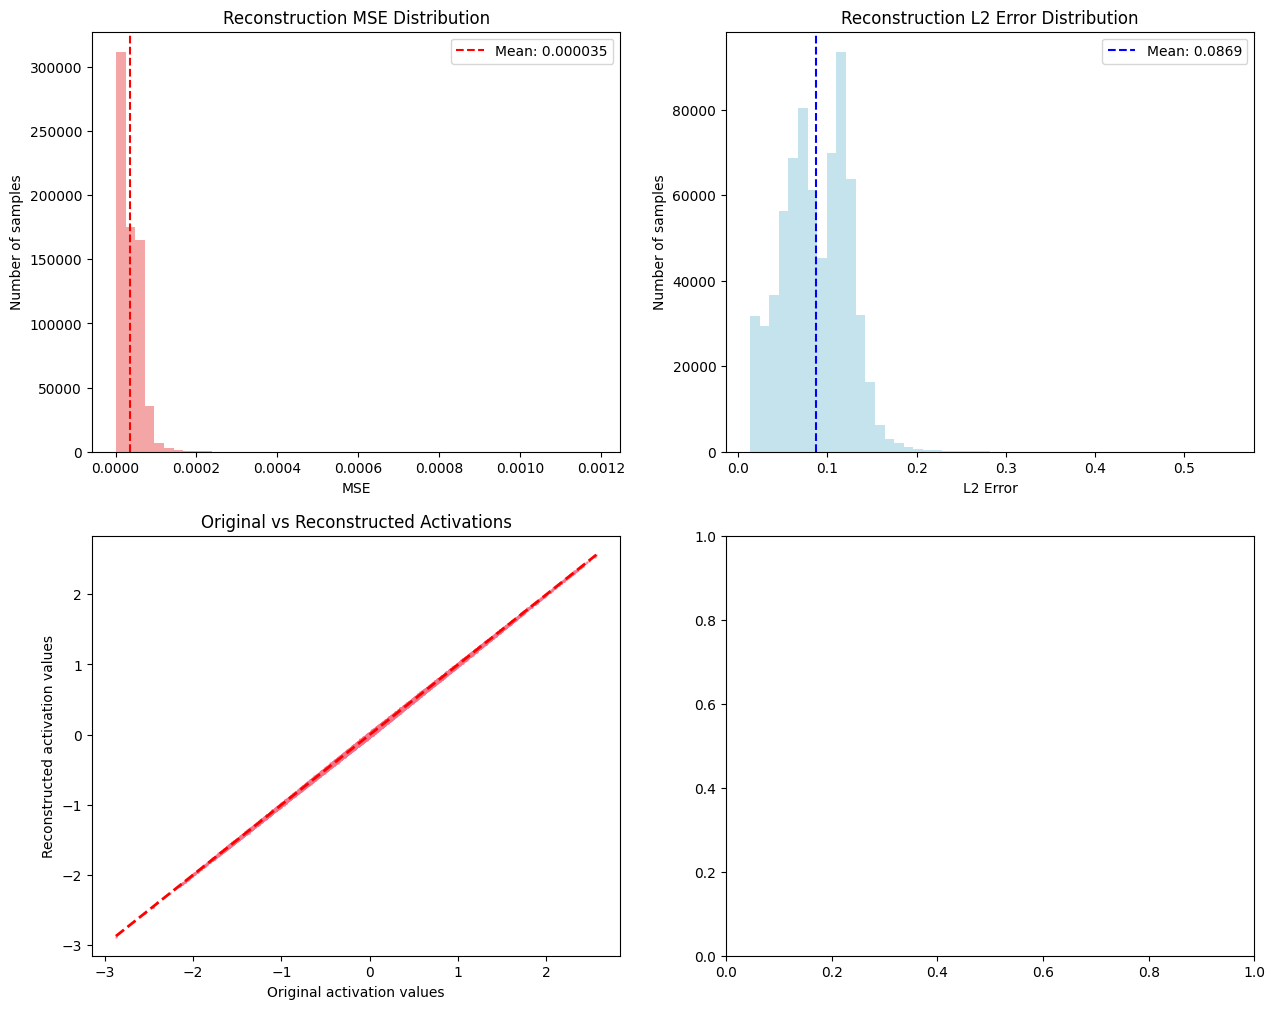

In [ ]:
"""### Visualize SAE Features for Insights"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def visualize_sae_features(features, activations, reconstructions, sae, model, act_name, val_loader, save_plots=True):
    """
    Comprehensive visualization of SAE features for insights

    Args:
        features: Extracted SAE features [num_samples, dict_size]
        activations: Original activations [num_samples, activation_dim]
        reconstructions: Reconstructed activations [num_samples, activation_dim]
        sae: Trained SAE model
        model: Original transformer model
        act_name: Activation hook name
        val_loader: Validation data loader
        save_plots: Whether to save plots to files
    """

    print("Creating SAE feature visualizations...")

    # Set up plotting style
    plt.style.use('default')
    sns.set_palette("husl")

    # Create figure directory
    import os
    os.makedirs("sae_visualizations", exist_ok=True)

    # 1. Feature Sparsity and Activation Patterns
    visualize_feature_sparsity(features, save_plots)

    # 2. Feature Activation Heatmap
    visualize_feature_heatmap(features, save_plots)

    # 3. Feature Frequency Distribution
    visualize_feature_frequency(features, save_plots)

    # 4. Reconstruction Quality Analysis
    visualize_reconstruction_quality(activations, reconstructions, save_plots)

    # 5. Feature Correlation Analysis
    visualize_feature_correlations(features, save_plots)

    # 6. Dimensionality Reduction Visualizations
    visualize_dimensionality_reduction(features, save_plots)

    # 7. Individual Feature Analysis
    visualize_individual_features(features, activations, sae, save_plots)

    # 8. Feature vs Activation Analysis
    visualize_feature_activation_analysis(features, activations, save_plots)

    print("✅ All visualizations completed! Check the 'sae_visualizations' folder.")

def visualize_feature_sparsity(features, save_plots=True):
    """Visualize sparsity patterns in SAE features"""

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Overall sparsity
    sparsity = (features == 0).float().mean()
    axes[0, 0].bar(['Non-zero', 'Zero'], [1-sparsity, sparsity], color=['orange', 'lightblue'])
    axes[0, 0].set_title(f'Overall Feature Sparsity: {sparsity:.3f}')
    axes[0, 0].set_ylabel('Proportion')

    # 2. Sparsity per sample
    sparsity_per_sample = (features == 0).float().mean(dim=1)
    axes[0, 1].hist(sparsity_per_sample.numpy(), bins=50, alpha=0.7, color='skyblue')
    axes[0, 1].set_title('Sparsity Distribution per Sample')
    axes[0, 1].set_xlabel('Sparsity (proportion of zeros)')
    axes[0, 1].set_ylabel('Number of samples')
    axes[0, 1].axvline(sparsity_per_sample.mean(), color='red', linestyle='--',
                       label=f'Mean: {sparsity_per_sample.mean():.3f}')
    axes[0, 1].legend()

    # 3. Feature activation frequency
    feature_activations = (features > 0).float()
    feature_frequency = feature_activations.mean(dim=0)
    axes[1, 0].hist(feature_frequency.numpy(), bins=30, alpha=0.7, color='lightgreen')
    axes[1, 0].set_title('Feature Activation Frequency Distribution')
    axes[1, 0].set_xlabel('Activation frequency')
    axes[1, 0].set_ylabel('Number of features')

    # 4. Top and bottom features
    top_features = feature_frequency.topk(10)
    bottom_features = feature_frequency.topk(10, largest=False)

    x_pos = np.arange(20)
    frequencies = torch.cat([top_features.values, bottom_features.values]).numpy()
    colors = ['green'] * 10 + ['red'] * 10

    axes[1, 1].bar(x_pos, frequencies, color=colors, alpha=0.7)
    axes[1, 1].set_title('Top 10 (Green) vs Bottom 10 (Red) Feature Frequencies')
    axes[1, 1].set_xlabel('Feature rank')
    axes[1, 1].set_ylabel('Activation frequency')

    plt.tight_layout()
    if save_plots:
        plt.savefig('sae_visualizations/feature_sparsity.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_feature_heatmap(features, save_plots=True):
    """Create heatmap of feature activations"""

    # Sample a subset for visualization (first 1000 samples, all features)
    sample_size = min(1000, features.shape[0])
    features_sample = features[:sample_size]

    # Create binary activation matrix
    activation_matrix = (features_sample > 0).float().numpy()

    plt.figure(figsize=(20, 12))

    # Create heatmap
    sns.heatmap(activation_matrix.T,
                cmap='Blues',
                cbar_kws={'label': 'Feature Active (1) / Inactive (0)'},
                xticklabels=False,
                yticklabels=False)

    plt.title(f'SAE Feature Activation Heatmap\n(Sample of {sample_size} activations)')
    plt.xlabel('Activation samples')
    plt.ylabel('SAE features')

    if save_plots:
        plt.savefig('sae_visualizations/feature_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_feature_frequency(features, save_plots=True):
    """Visualize feature frequency patterns"""

    feature_activations = (features > 0).float()
    feature_frequency = feature_activations.mean(dim=0)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Feature frequency bar plot (top 20)
    top_20_features = feature_frequency.topk(20)
    axes[0].bar(range(20), top_20_features.values.numpy(), color='skyblue', alpha=0.7)
    axes[0].set_title('Top 20 Most Active Features')
    axes[0].set_xlabel('Feature rank')
    axes[0].set_ylabel('Activation frequency')
    axes[0].set_xticks(range(20))
    axes[0].set_xticklabels([f'F{i}' for i in top_20_features.indices.numpy()], rotation=45)

    # 2. Cumulative feature activation
    sorted_frequencies = torch.sort(feature_frequency, descending=True).values
    cumulative = torch.cumsum(sorted_frequencies, dim=0)
    axes[1].plot(range(len(cumulative)), cumulative.numpy(), linewidth=2, color='red')
    axes[1].set_title('Cumulative Feature Activation')
    axes[1].set_xlabel('Feature rank')
    axes[1].set_ylabel('Cumulative activation frequency')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_plots:
        plt.savefig('sae_visualizations/feature_frequency.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_reconstruction_quality(activations, reconstructions, save_plots=True):
    """Analyze reconstruction quality"""

    # Compute reconstruction errors
    mse_per_sample = torch.nn.functional.mse_loss(activations, reconstructions, reduction='none').mean(dim=1)
    l2_error_per_sample = torch.norm(activations - reconstructions, dim=1)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. MSE distribution
    axes[0, 0].hist(mse_per_sample.numpy(), bins=50, alpha=0.7, color='lightcoral')
    axes[0, 0].set_title('Reconstruction MSE Distribution')
    axes[0, 0].set_xlabel('MSE')
    axes[0, 0].set_ylabel('Number of samples')
    axes[0, 0].axvline(mse_per_sample.mean(), color='red', linestyle='--',
                       label=f'Mean: {mse_per_sample.mean():.6f}')
    axes[0, 0].legend()

    # 2. L2 error distribution
    axes[0, 1].hist(l2_error_per_sample.numpy(), bins=50, alpha=0.7, color='lightblue')
    axes[0, 1].set_title('Reconstruction L2 Error Distribution')
    axes[0, 1].set_xlabel('L2 Error')
    axes[0, 1].set_ylabel('Number of samples')
    axes[0, 1].axvline(l2_error_per_sample.mean(), color='blue', linestyle='--',
                       label=f'Mean: {l2_error_per_sample.mean():.4f}')
    axes[0, 1].legend()

    # 3. Scatter plot: original vs reconstructed (first 1000 samples)
    sample_size = min(1000, activations.shape[0])
    orig_sample = activations[:sample_size].flatten()
    recon_sample = reconstructions[:sample_size].flatten()

    axes[1, 0].scatter(orig_sample.numpy(), recon_sample.numpy(), alpha=0.5, s=1)
    axes[1, 0].plot([orig_sample.min(), orig_sample.max()],
                    [orig_sample.min(), orig_sample.max()], 'r--', linewidth=2)
    axes[1, 0].set_title('Original vs Reconstructed Activations')
    axes[1, 0].set_xlabel('Original activation values')
    axes[1, 0].set_ylabel('Reconstructed activation values')

    # 4. Reconstruction error vs sparsity
    sparsity_per_sample = (features == 0).float().mean(dim=1)
    axes[1, 1].scatter(sparsity_per_sample.cpu().numpy(), mse_per_sample.numpy(), alpha=0.5, s=1)
    axes[1, 1].set_title('Reconstruction Error vs Feature Sparsity')
    axes[1, 1].set_xlabel('Feature sparsity')
    axes[1, 1].set_ylabel('Reconstruction MSE')

    plt.tight_layout()
    if save_plots:
        plt.savefig('sae_visualizations/reconstruction_quality.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_feature_correlations(features, save_plots=True):
    """Analyze correlations between features"""

    # Compute feature correlation matrix
    feature_activations = (features > 0).float()
    correlation_matrix = torch.corrcoef(feature_activations.T)

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix.numpy(),
                cmap='RdBu_r',
                center=0,
                square=True,
                cbar_kws={'label': 'Correlation coefficient'})

    plt.title('SAE Feature Correlation Matrix')
    plt.xlabel('SAE features')
    plt.ylabel('SAE features')

    if save_plots:
        plt.savefig('sae_visualizations/feature_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_dimensionality_reduction(features, save_plots=True):
    """Visualize features using dimensionality reduction"""

    # Sample data for faster computation
    sample_size = min(5000, features.shape[0])
    features_sample = features[:sample_size]

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # 1. PCA visualization
    print("Computing PCA...")
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features_sample.numpy())

    # Color by sparsity
    sparsity_per_sample = (features_sample == 0).float().mean(dim=1)

    scatter1 = axes[0].scatter(features_pca[:, 0], features_pca[:, 1],
                              c=sparsity_per_sample.numpy(), cmap='viridis', alpha=0.6)
    axes[0].set_title(f'PCA of SAE Features\nExplained variance: {pca.explained_variance_ratio_.sum():.3f}')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
    plt.colorbar(scatter1, ax=axes[0], label='Feature sparsity')

    # 2. t-SNE visualization
    print("Computing t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    features_tsne = tsne.fit_transform(features_sample.numpy())

    scatter2 = axes[1].scatter(features_tsne[:, 0], features_tsne[:, 1],
                              c=sparsity_per_sample.numpy(), cmap='viridis', alpha=0.6)
    axes[1].set_title('t-SNE of SAE Features')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    plt.colorbar(scatter2, ax=axes[1], label='Feature sparsity')

    plt.tight_layout()
    if save_plots:
        plt.savefig('sae_visualizations/dimensionality_reduction.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_individual_features(features, activations, sae, save_plots=True):
    """Analyze individual SAE features"""

    # Get top 5 most active features
    feature_activations = (features > 0).float()
    feature_frequency = feature_activations.mean(dim=0)
    top_features = feature_frequency.topk(5)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    for i, (feature_idx, freq) in enumerate(zip(top_features.indices, top_features.values)):
        row = i // 3
        col = i % 3

        # Get feature values for this feature
        feature_values = features[:, feature_idx]

        # Plot feature value distribution
        axes[row, col].hist(feature_values.numpy(), bins=50, alpha=0.7, color='orange')
        axes[row, col].set_title(f'Feature {feature_idx.item()}\nActivation freq: {freq.item():.3f}')
        axes[row, col].set_xlabel('Feature value')
        axes[row, col].set_ylabel('Count')

        # Add vertical line for zero
        axes[row, col].axvline(0, color='red', linestyle='--', alpha=0.7)

    # Last subplot: feature decoder weights
    if hasattr(sae, 'decoder') and hasattr(sae.decoder, 'weight'):
        decoder_weights = sae.decoder.weight.data.cpu()
        axes[1, 2].imshow(decoder_weights.numpy(), cmap='RdBu_r', aspect='auto')
        axes[1, 2].set_title('SAE Decoder Weights')
        axes[1, 2].set_xlabel('SAE features')
        axes[1, 2].set_ylabel('Activation dimensions')
        plt.colorbar(axes[1, 2].images[0], ax=axes[1, 2])

    plt.tight_layout()
    if save_plots:
        plt.savefig('sae_visualizations/individual_features.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_feature_activation_analysis(features, activations, save_plots=True):
    """Analyze relationship between features and original activations"""

    # Sample data for faster computation
    sample_size = min(2000, features.shape[0])
    features_sample = features[:sample_size]
    activations_sample = activations[:sample_size]

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Feature values vs activation magnitude
    activation_magnitude = torch.norm(activations_sample, dim=1)
    feature_magnitude = torch.norm(features_sample, dim=1)

    axes[0, 0].scatter(activation_magnitude.numpy(), feature_magnitude.numpy(), alpha=0.5, s=1)
    axes[0, 0].set_title('Feature Magnitude vs Activation Magnitude')
    axes[0, 0].set_xlabel('Original activation magnitude')
    axes[0, 0].set_ylabel('SAE feature magnitude')

    # 2. Number of active features vs activation magnitude
    num_active_features = (features_sample > 0).float().sum(dim=1)
    axes[0, 1].scatter(activation_magnitude.numpy(), num_active_features.numpy(), alpha=0.5, s=1)
    axes[0, 1].set_title('Number of Active Features vs Activation Magnitude')
    axes[0, 1].set_xlabel('Original activation magnitude')
    axes[0, 1].set_ylabel('Number of active features')

    # 3. Feature sparsity vs activation magnitude
    sparsity_per_sample = (features_sample == 0).float().mean(dim=1)
    axes[1, 0].scatter(activation_magnitude.numpy(), sparsity_per_sample.numpy(), alpha=0.5, s=1)
    axes[1, 0].set_title('Feature Sparsity vs Activation Magnitude')
    axes[1, 0].set_xlabel('Original activation magnitude')
    axes[1, 0].set_ylabel('Feature sparsity')

    # 4. Distribution of activation magnitudes
    axes[1, 1].hist(activation_magnitude.numpy(), bins=50, alpha=0.7, color='lightgreen')
    axes[1, 1].set_title('Distribution of Activation Magnitudes')
    axes[1, 1].set_xlabel('Activation magnitude')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].axvline(activation_magnitude.mean(), color='red', linestyle='--',
                       label=f'Mean: {activation_magnitude.mean():.3f}')
    axes[1, 1].legend()

    plt.tight_layout()
    if save_plots:
        plt.savefig('sae_visualizations/feature_activation_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Example usage:
visualize_sae_features(all_features, all_activations, all_reconstructions,
                      trainer.ae, model, act_name, val_loader)


In [ ]:

"""### Load a trained SAE and extract features (Alternative method)"""

# This section shows how to load a previously trained SAE and extract features
# You can use this if you want to load a pre-trained SAE instead of training from scratch

def load_trained_sae_and_extract_features(sae_path=None, use_pretrained=False):
    """
    Load a trained SAE and extract features from your datasets

    Args:
        sae_path: Path to saved SAE weights (if None, uses the one we just trained)
        use_pretrained: Whether to download a pre-trained SAE from HuggingFace
    """

    if use_pretrained:
        # Load pre-trained SAE from HuggingFace (example)
        from huggingface_hub import hf_hub_download
        from IPython.display import clear_output

        REPO_ID = "sojup/entity_binding_sae"
        FILENAME = "blocks.1.hook_resid_pre_epoch_59_d128.pt"

        weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)
        try:
            from IPython.display import clear_output
            clear_output()
        except ImportError:
            pass  # clear_output not available, continue anyway
        sae_path = weights_path

    # Create SAE instance
    sae = AutoEncoder(
        activation_dim=model.cfg.d_model,
        dict_size=128  # Make sure this matches the trained SAE
    )

    # Load weights
    if sae_path is None:
        sae_path = f"{act_name}_trained.pt"  # Use the one we just trained

    try:
        sae.load_state_dict(torch.load(sae_path, map_location=device))
        print(f"Successfully loaded SAE from {sae_path}")
    except FileNotFoundError:
        print(f"SAE file not found at {sae_path}. Please train a SAE first.")
        return None, None, None

    sae = sae.to(device)
    sae.eval()

    # Extract features from validation set
    print("Extracting SAE features from validation set...")
    val_loader = DataLoader(val_dataset, batch_size=64, collate_fn=collate_fn)

    all_features = []
    all_activations = []
    all_reconstructions = []

    with torch.no_grad():
        for toks, _ in val_loader:
            toks = toks.to(device)
            cache = model.run_with_cache(toks, names_filter=[act_name])[1]
            acts = cache[act_name]
            acts = acts.reshape(-1, acts.size(-1))

            # Extract features
            features = sae.encode(acts)
            reconstruction = sae.decode(features)

            all_features.append(features.cpu())
            all_activations.append(acts.cpu())
            all_reconstructions.append(reconstruction.cpu())

    # Concatenate all features
    all_features = torch.cat(all_features, dim=0)
    all_activations = torch.cat(all_activations, dim=0)
    all_reconstructions = torch.cat(all_reconstructions, dim=0)

    print(f"Extracted features shape: {all_features.shape}")

    return all_features, all_activations, all_reconstructions

# Example usage:
# features, activations, reconstructions = load_trained_sae_and_extract_features()

# You can also load a specific SAE file:
# features, activations, reconstructions = load_trained_sae_and_extract_features(sae_path="path/to/your/sae.pt")